#  Term Deposit Subscription Prediction
### Bank Marketing Dataset — Full ML Pipeline

**Objective:** Predict whether a customer will subscribe to a term deposit (`yes`/`no`) based on demographic and campaign features.

---
**Pipeline Overview:**
1. Install & Import Libraries
2. Load & Explore Dataset
3. Data Preprocessing & Encoding
4. Train-Test Split + Handle Class Imbalance
5. Train Models (Logistic Regression + Random Forest)
6. Evaluate: Confusion Matrix, F1-Score, ROC Curve
7. Explainability with SHAP (5+ predictions explained)

##  Step 1: Install Required Libraries

In [1]:
# Run this cell first in Google Colab
!pip install shap imbalanced-learn --quiet

##  Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_curve, auc, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
print(' All libraries imported successfully!')

 All libraries imported successfully!


## Step 3: Load the Dataset

> **Upload Instructions:**  
> Run the cell below. A file picker will appear — upload your `bank-full.csv` file.  
> *(The file uses semicolons `;` as separators — handled automatically below)*

In [3]:
from google.colab import files
uploaded = files.upload()  # Upload bank-full.csv here

Saving bank-full.csv to bank-full (1).csv


In [4]:
# Load the CSV (semicolon-separated)
df = pd.read_csv('bank-full.csv', sep=';')

print(f' Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n Columns:\n{list(df.columns)}')
df.head()

 Dataset Shape: 45,211 rows × 17 columns

 Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


##  Step 4: Exploratory Data Analysis (EDA)

In [5]:
# Basic info
print('=== Data Types & Non-Null Counts ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

=== Statistical Summary ===


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
# Check for missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else ' No missing values found!')

=== Missing Values ===
 No missing values found!


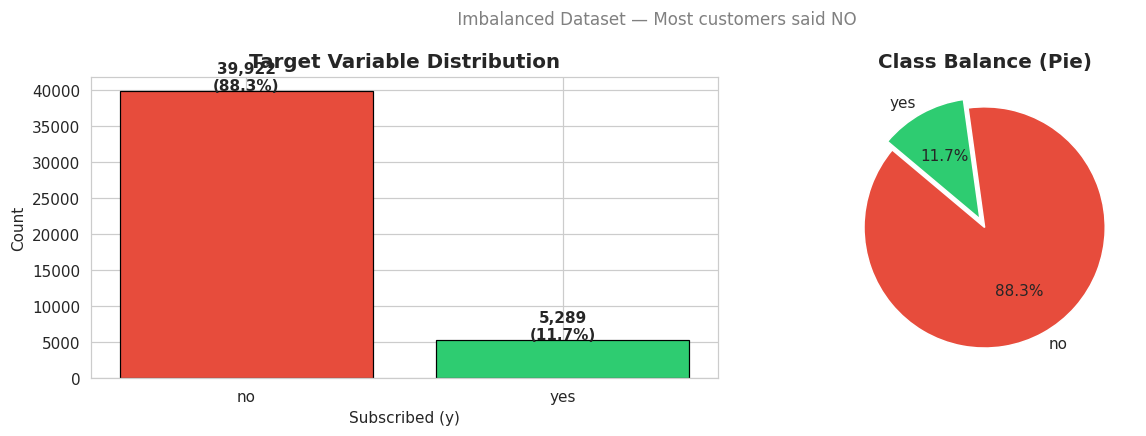


Class ratio  →  no : yes  =  39922 : 5289  (7.5:1)


In [7]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['y'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 100, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, explode=(0, 0.08))
axes[1].set_title('Class Balance (Pie)', fontsize=13, fontweight='bold')

plt.suptitle(' Imbalanced Dataset — Most customers said NO', fontsize=11, color='gray')
plt.tight_layout()
plt.show()

print(f'\nClass ratio  →  no : yes  =  {counts["no"]} : {counts["yes"]}  ({counts["no"]/counts["yes"]:.1f}:1)')

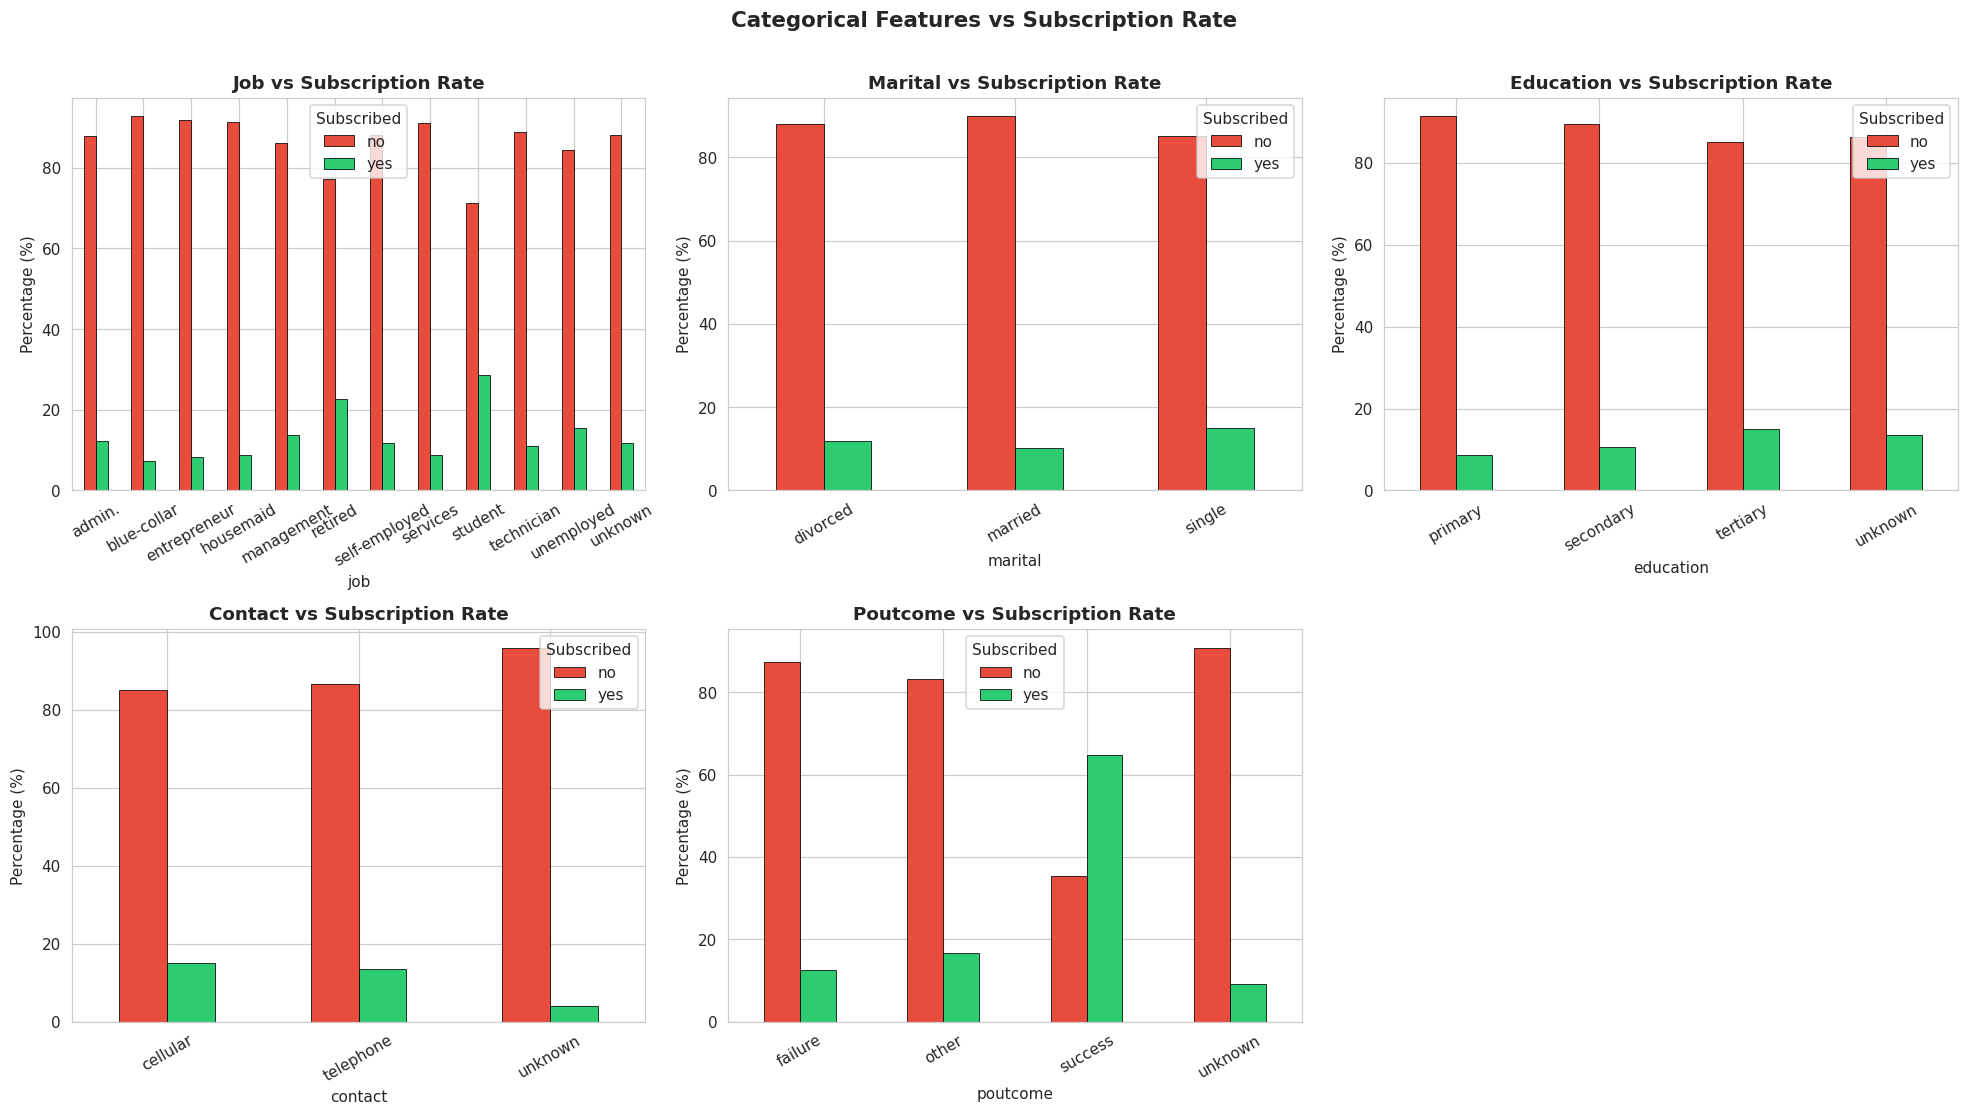

In [8]:
# Categorical features vs Target
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
            edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col.capitalize()} vs Subscription Rate', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Subscribed')

axes[5].set_visible(False)  # Hide unused subplot
plt.suptitle('Categorical Features vs Subscription Rate', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

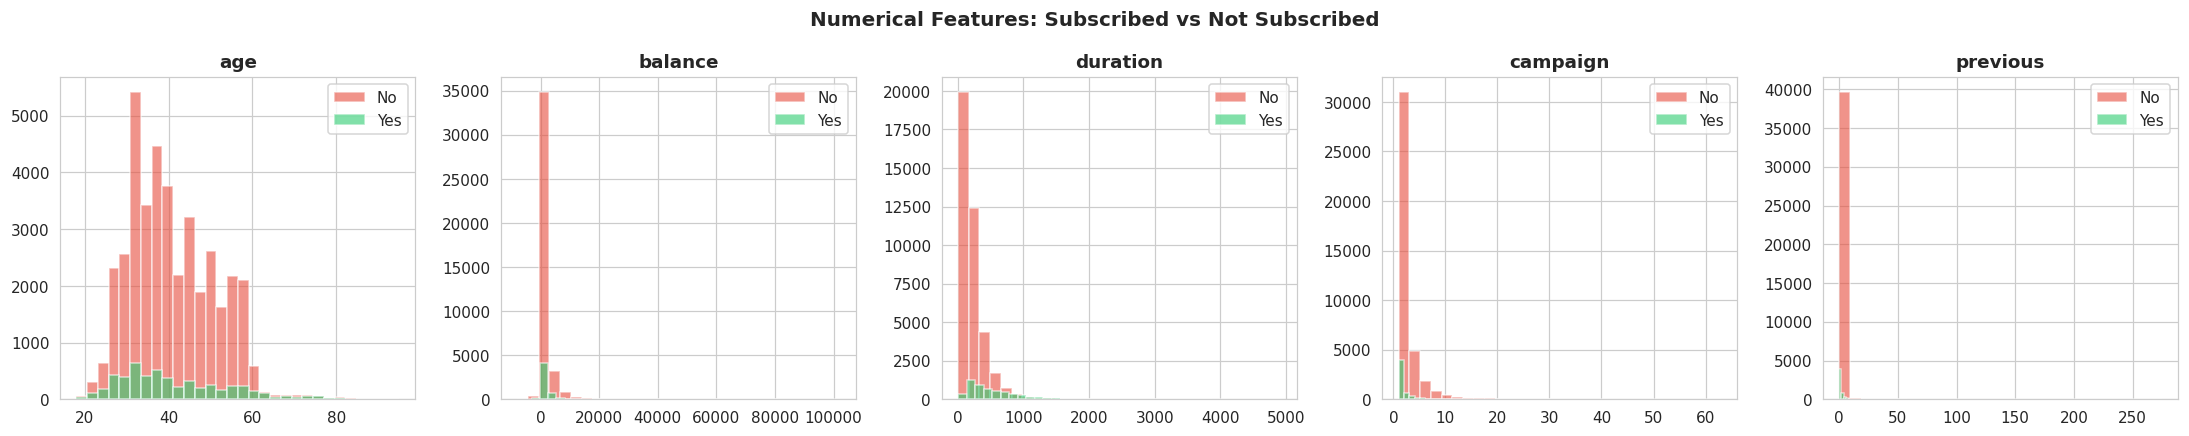

In [9]:
# Numerical features distribution by target
num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))

for i, col in enumerate(num_cols):
    df[df['y']=='no'][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                 color='#e74c3c', label='No')
    df[df['y']=='yes'][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                  color='#2ecc71', label='Yes')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()

plt.suptitle('Numerical Features: Subscribed vs Not Subscribed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

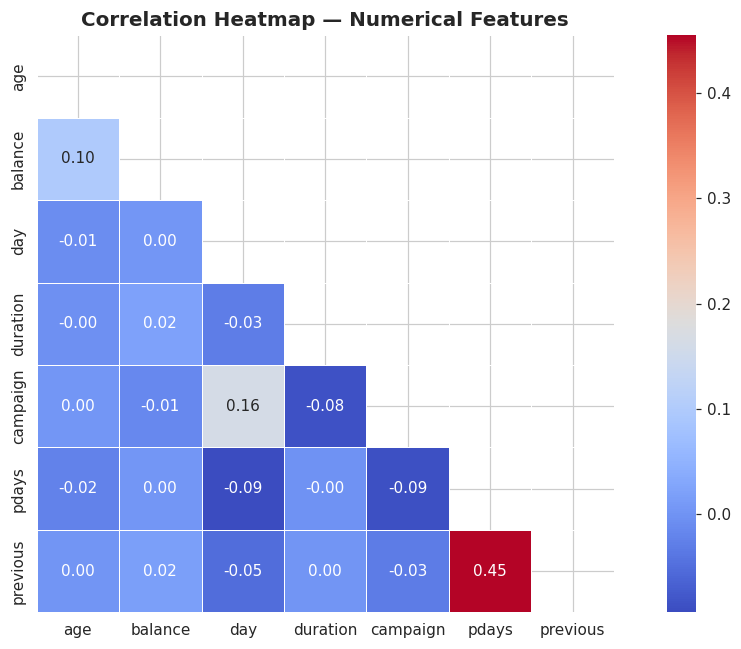

In [10]:
# Correlation heatmap (numerical only)
num_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 5: Data Preprocessing & Feature Encoding

**Categorical columns** are converted to numbers using:
- **Label Encoding** for binary columns (yes/no)
- **One-Hot Encoding** for multi-class columns (job, marital, etc.)

In [12]:
# Work on a copy
df_enc = df.copy()

# ── Binary columns: Label Encode (yes=1, no=0) ──────────────────────────────
binary_cols = ['default', 'housing', 'loan', 'y']
le = LabelEncoder()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])
    print(f'  ✔ Label Encoded  →  {col}')

# ── Multi-class columns: One-Hot Encode ─────────────────────────────────────
ohe_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True)
print(f'\n  ✔ One-Hot Encoded → {ohe_cols}')

print(f'\n Encoded dataset shape: {df_enc.shape}')
df_enc.head(3)

  ✔ Label Encoded  →  default
  ✔ Label Encoded  →  housing
  ✔ Label Encoded  →  loan
  ✔ Label Encoded  →  y

  ✔ One-Hot Encoded → ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

 Encoded dataset shape: (45211, 43)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,44,0,29,1,0,5,151,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,33,0,2,1,1,5,76,1,-1,0,...,False,False,False,True,False,False,False,False,False,True


In [13]:
# ── Features & Target ───────────────────────────────────────────────────────
X = df_enc.drop('y', axis=1)
y_target = df_enc['y']

print(f'Features (X): {X.shape}  |  Target (y): {y_target.shape}')
print(f'Class counts before SMOTE  →  {dict(y_target.value_counts())}')

# ── Train-Test Split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)
print(f'\nTrain size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')

Features (X): (45211, 42)  |  Target (y): (45211,)
Class counts before SMOTE  →  {0: np.int64(39922), 1: np.int64(5289)}

Train size: 36,168  |  Test size: 9,043


In [14]:
# ── Handle Class Imbalance with SMOTE ───────────────────────────────────────
# SMOTE creates synthetic minority (yes) samples in training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('SMOTE Applied!')
print(f'Before SMOTE  →  {dict(y_train.value_counts())}')
print(f'After  SMOTE  →  {dict(pd.Series(y_train_sm).value_counts())}')

SMOTE Applied!
Before SMOTE  →  {0: np.int64(31937), 1: np.int64(4231)}
After  SMOTE  →  {0: np.int64(31937), 1: np.int64(31937)}


In [15]:
# ── Feature Scaling (for Logistic Regression) ───────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print(' Features scaled with StandardScaler')

 Features scaled with StandardScaler


##  Step 6: Train Classification Models

In [16]:
# ── Model 1: Logistic Regression ────────────────────────────────────────────
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_sm)

y_pred_lr   = lr.predict(X_test_scaled)
y_proba_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression trained!')

Training Logistic Regression...
Logistic Regression trained!


In [17]:
# ── Model 2: Random Forest ──────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)  # RF doesn't need scaling

y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print(' Random Forest trained!')

Training Random Forest...
 Random Forest trained!


##  Step 7: Model Evaluation
### 7A — Classification Report & F1-Score

In [18]:
def print_report(name, y_true, y_pred):
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=['No (0)', 'Yes (1)']))
    f1 = f1_score(y_true, y_pred)
    print(f'  ➤  F1-Score (Yes class): {f1:.4f}')

print_report('LOGISTIC REGRESSION', y_test, y_pred_lr)
print_report('RANDOM FOREST',       y_test, y_pred_rf)


  LOGISTIC REGRESSION
              precision    recall  f1-score   support

      No (0)       0.93      0.94      0.94      7985
     Yes (1)       0.51      0.46      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.72      0.70      0.71      9043
weighted avg       0.88      0.88      0.88      9043

  ➤  F1-Score (Yes class): 0.4806

  RANDOM FOREST
              precision    recall  f1-score   support

      No (0)       0.95      0.94      0.94      7985
     Yes (1)       0.56      0.61      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.77      0.76      9043
weighted avg       0.90      0.90      0.90      9043

  ➤  F1-Score (Yes class): 0.5856


### 7B — Confusion Matrices

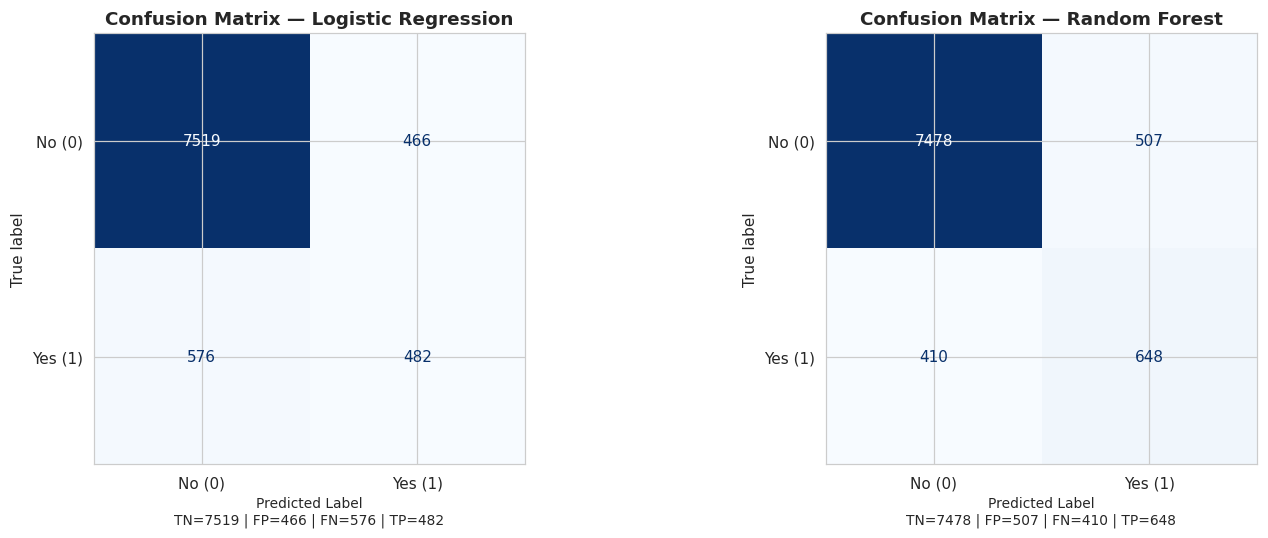

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_info = [
    ('Logistic Regression', y_pred_lr, '#3498db'),
    ('Random Forest',       y_pred_rf, '#2ecc71'),
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No (0)', 'Yes (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')

    # Annotate with extra stats
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted Label\n'
                  f'TN={tn} | FP={fp} | FN={fn} | TP={tp}', fontsize=9)

plt.tight_layout()
plt.show()

### 7C — ROC Curves

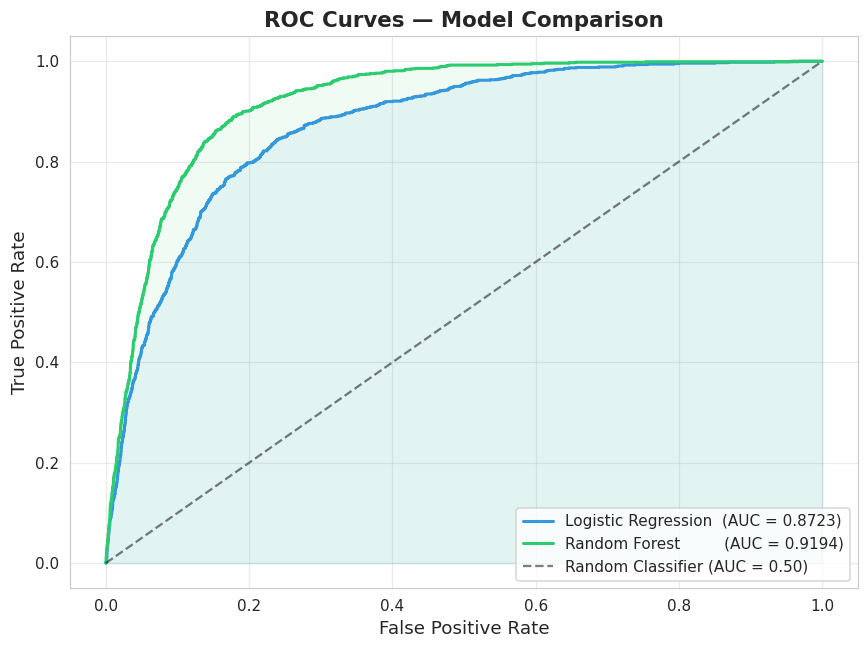


 AUC Summary:
   Logistic Regression : 0.8723
   Random Forest       : 0.9194
   Winner              : Random Forest 


In [21]:
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='#3498db', lw=2,
         label=f'Logistic Regression  (AUC = {auc_lr:.4f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2,
         label=f'Random Forest         (AUC = {auc_rf:.4f})')

# Baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.50)')

plt.fill_between(fpr_rf, tpr_rf, alpha=0.07, color='#2ecc71')
plt.fill_between(fpr_lr, tpr_lr, alpha=0.07, color='#3498db')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\n AUC Summary:')
print(f'   Logistic Regression : {auc_lr:.4f}')
print(f'   Random Forest       : {auc_rf:.4f}')
print(f'   Winner              : {"Random Forest" if auc_rf >= auc_lr else "Logistic Regression"} ')

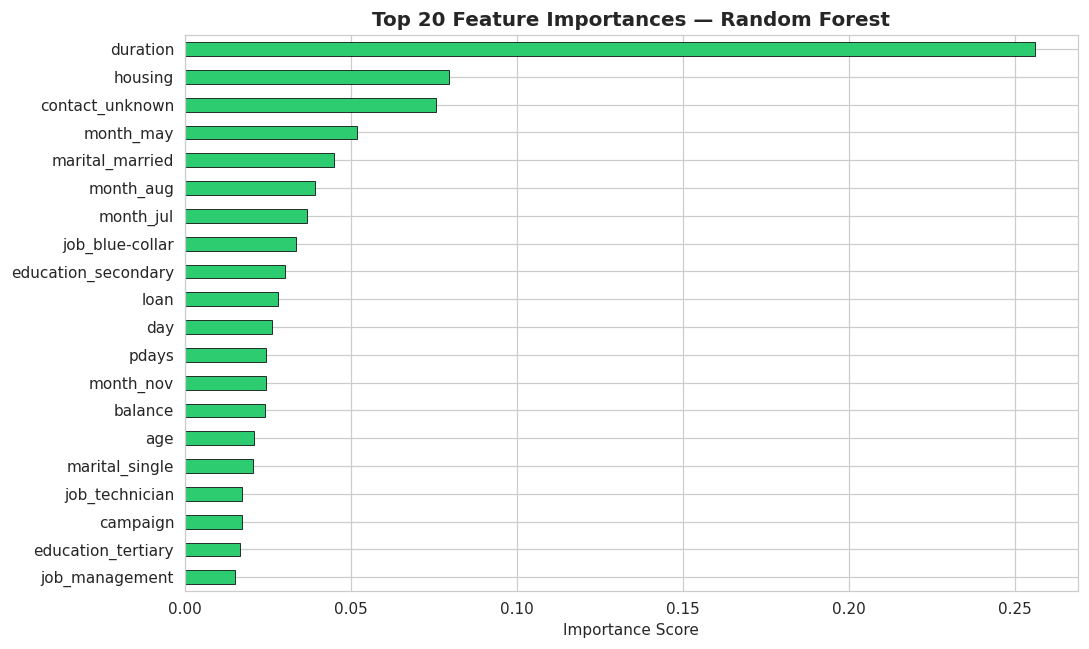

In [22]:
# ── Feature Importance (Random Forest) ──────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top20    = feat_imp.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='#2ecc71', edgecolor='black', linewidth=0.5)
plt.title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

##  Step 8: Explainability with SHAP

**SHAP (SHapley Additive exPlanations)** explains *why* the model made each prediction.
- Positive SHAP → pushes prediction toward **YES** (subscribe)
- Negative SHAP → pushes prediction toward **NO** (don't subscribe)

In [23]:
# Initialize SHAP TreeExplainer for Random Forest
print('Computing SHAP values (this may take ~30 seconds)...')

# Use a sample of test data for SHAP (full test set can be slow)
X_test_sample = X_test.sample(n=500, random_state=42).reset_index(drop=True)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

# shap_values[1] = SHAP values for class 1 (YES)
sv_yes = shap_values[1]

print(' SHAP values computed!')
print(f'   Shape: {sv_yes.shape}  (500 samples × {X_test_sample.shape[1]} features)')

Computing SHAP values (this may take ~30 seconds)...
 SHAP values computed!
   Shape: (42, 2)  (500 samples × 42 features)


In [25]:
# ── SHAP Setup (Modern API — fixes AssertionError) ──────────────────────────
print('Computing SHAP values (this may take ~30 seconds)...')

X_test_sample = X_test.sample(n=500, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(rf)

#  Modern API: explainer(X) instead of explainer.shap_values(X)
shap_explanation = explainer(X_test_sample)

# Slice class 1 (YES) — shape is now correct (500 × n_features)
exp_yes = shap_explanation[:, :, 1]
sv_yes  = exp_yes.values   # raw numpy array for text explanations

print(' SHAP values computed!')
print(f'   Shape: {sv_yes.shape}')
print(f'   Base value: {exp_yes.base_values[0]:.4f}')

Computing SHAP values (this may take ~30 seconds)...
 SHAP values computed!
   Shape: (500, 42)
   Base value: 0.5002


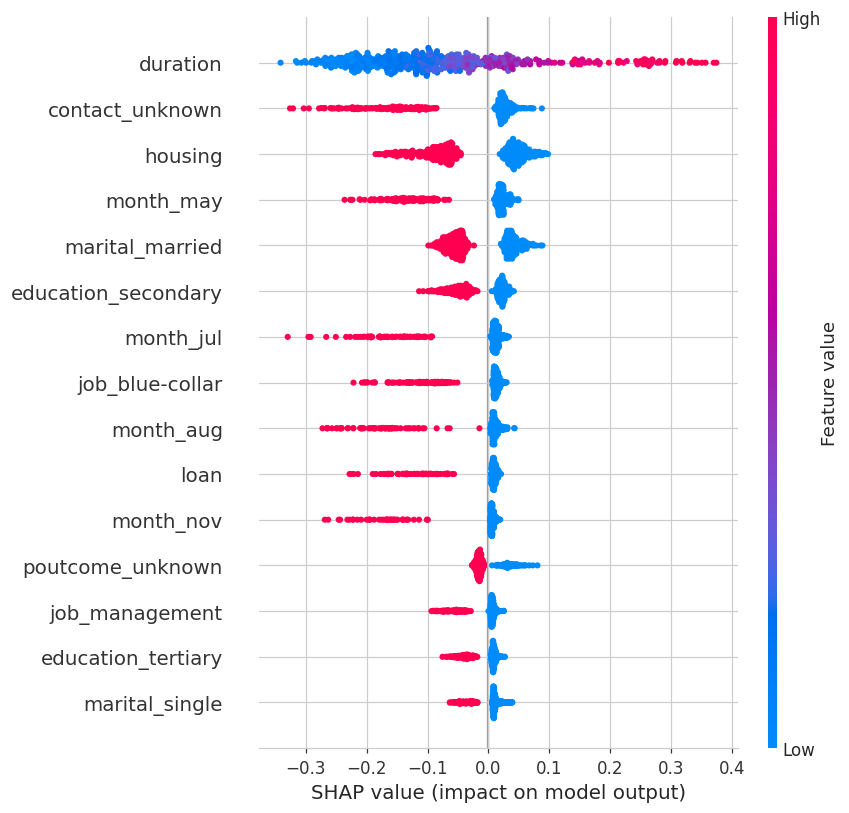

In [26]:
# ── SHAP Beeswarm (shows direction of impact per feature) ──────────────────
shap.summary_plot(sv_yes, X_test_sample, max_display=15)

In [27]:
# ── Individual Prediction Explanations — 5 Customers ───────────────────────

def explain_prediction(idx, X_sample, shap_vals, model, title_suffix=''):
    pred      = model.predict(X_sample.iloc[[idx]])[0]
    proba     = model.predict_proba(X_sample.iloc[[idx]])[0][1]
    label     = ' YES (Subscribe)' if pred == 1 else ' NO (Not Subscribe)'

    print(f'\n{"─"*60}')
    print(f'Customer #{idx} {title_suffix}')
    print(f'  Prediction : {label}')
    print(f'  Probability of subscribing: {proba:.2%}')
    print(f'{"─"*60}')

    # Top 5 features influencing this prediction
    feat_shap = pd.Series(shap_vals[idx], index=X_sample.columns)
    top_pos   = feat_shap.nlargest(3)
    top_neg   = feat_shap.nsmallest(3)

    print('  Top features PUSHING toward YES:')
    for f, v in top_pos.items():
        actual = X_sample.iloc[idx][f]
        print(f'    + {f:35s} = {actual:>8.3f}   (SHAP: +{v:.4f})')

    print('  Top features PUSHING toward NO:')
    for f, v in top_neg.items():
        actual = X_sample.iloc[idx][f]
        print(f'    - {f:35s} = {actual:>8.3f}   (SHAP: {v:.4f})')

# Pick 5 diverse customers
# ── Find examples of both predicted YES and NO ──────────────────────────────
preds_sample = rf.predict(X_test_sample)
yes_idxs = np.where(preds_sample == 1)[0][:3]  # 3 predicted YES
no_idxs  = np.where(preds_sample == 0)[0][:2]  # 2 predicted NO
chosen   = list(yes_idxs) + list(no_idxs)

labels = ['(Predicted: Subscribe)'] * 3 + ['(Predicted: Not Subscribe)'] * 2

for idx, lbl in zip(chosen, labels):
    explain_prediction(idx, X_test_sample, sv_yes, rf, lbl)


────────────────────────────────────────────────────────────
Customer #2 (Predicted: Subscribe)
  Prediction :  YES (Subscribe)
  Probability of subscribing: 81.90%
────────────────────────────────────────────────────────────
  Top features PUSHING toward YES:
    + housing                             =    0.000   (SHAP: +0.0654)
    + poutcome_success                    =    1.000   (SHAP: +0.0587)
    + poutcome_unknown                    =    0.000   (SHAP: +0.0423)
  Top features PUSHING toward NO:
    - job_management                      =    1.000   (SHAP: -0.0538)
    - marital_single                      =    1.000   (SHAP: -0.0402)
    - education_tertiary                  =    1.000   (SHAP: -0.0362)

────────────────────────────────────────────────────────────
Customer #6 (Predicted: Subscribe)
  Prediction :  YES (Subscribe)
  Probability of subscribing: 86.22%
────────────────────────────────────────────────────────────
  Top features PUSHING toward YES:
    + housing   

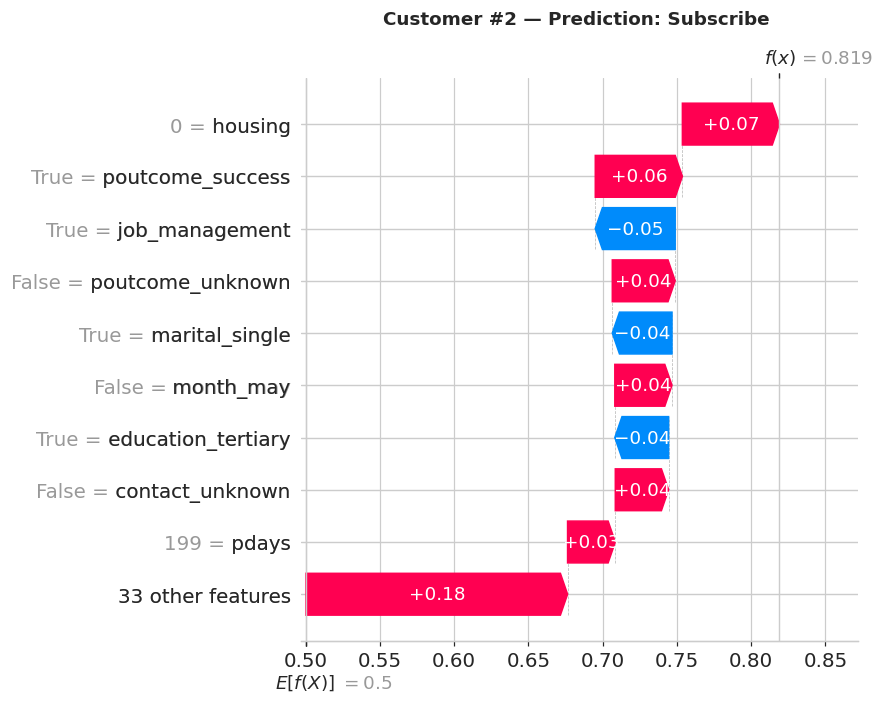

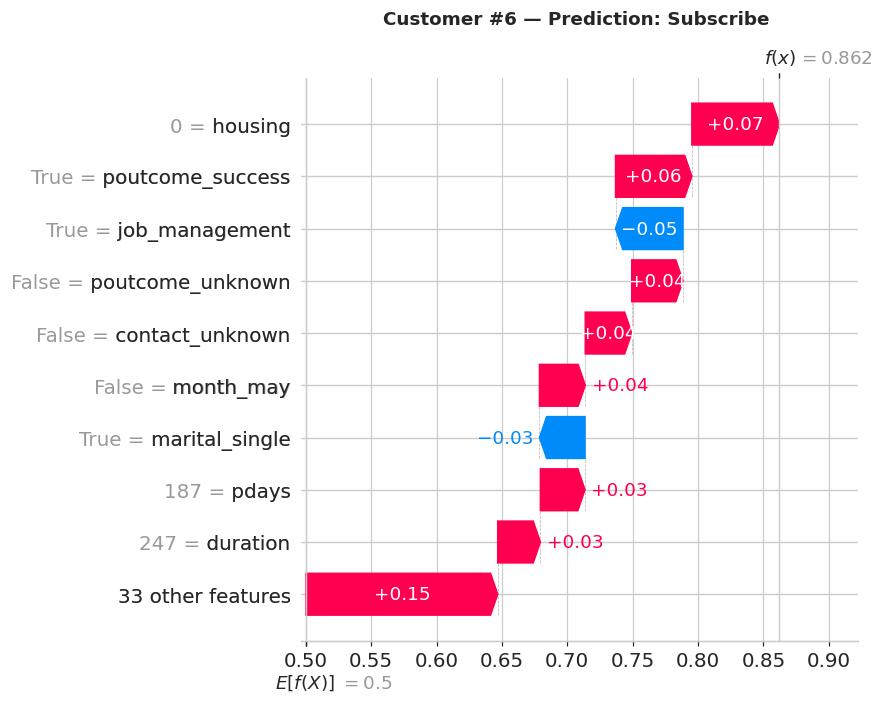

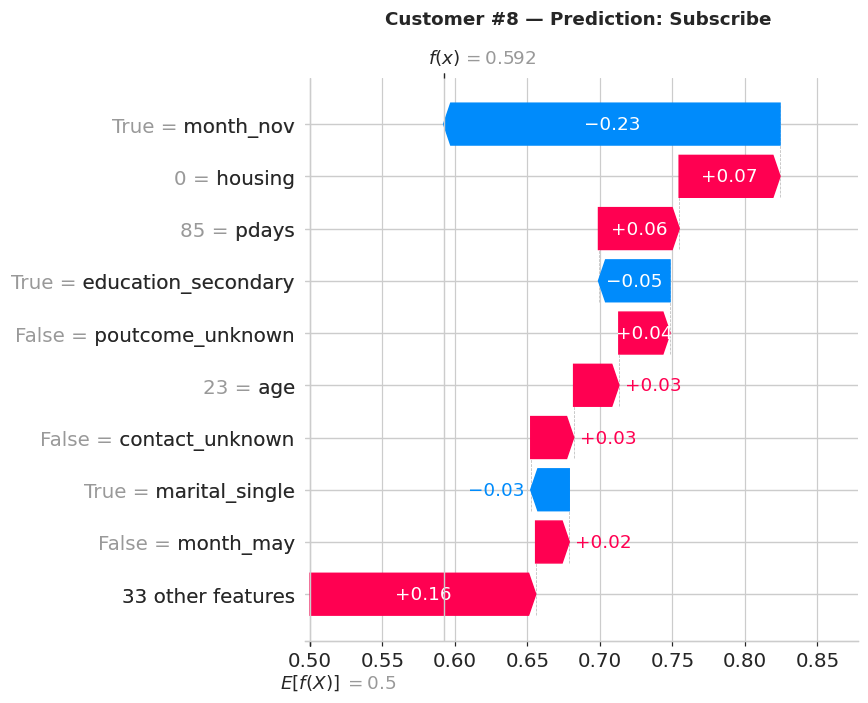

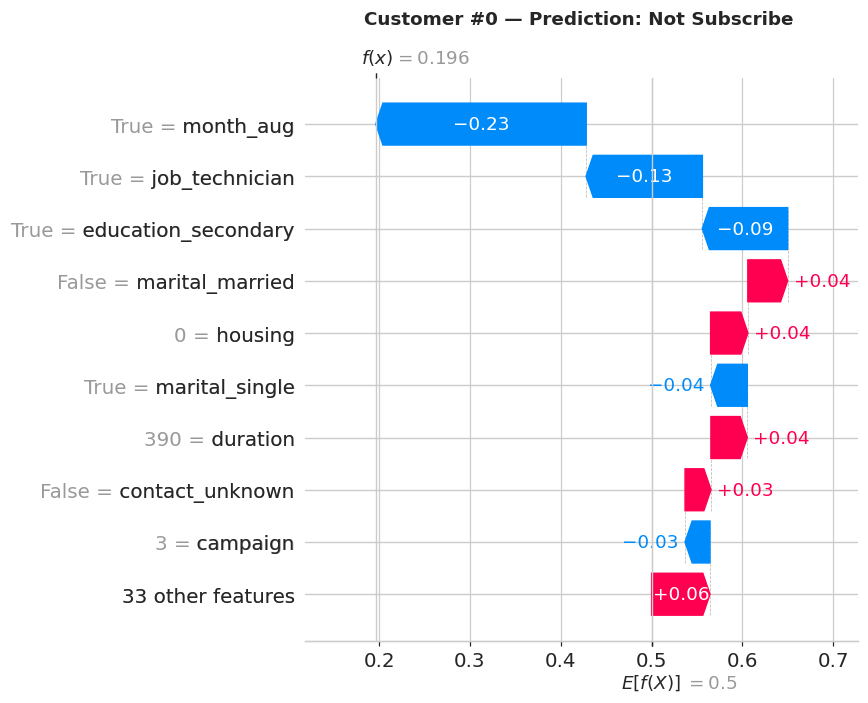

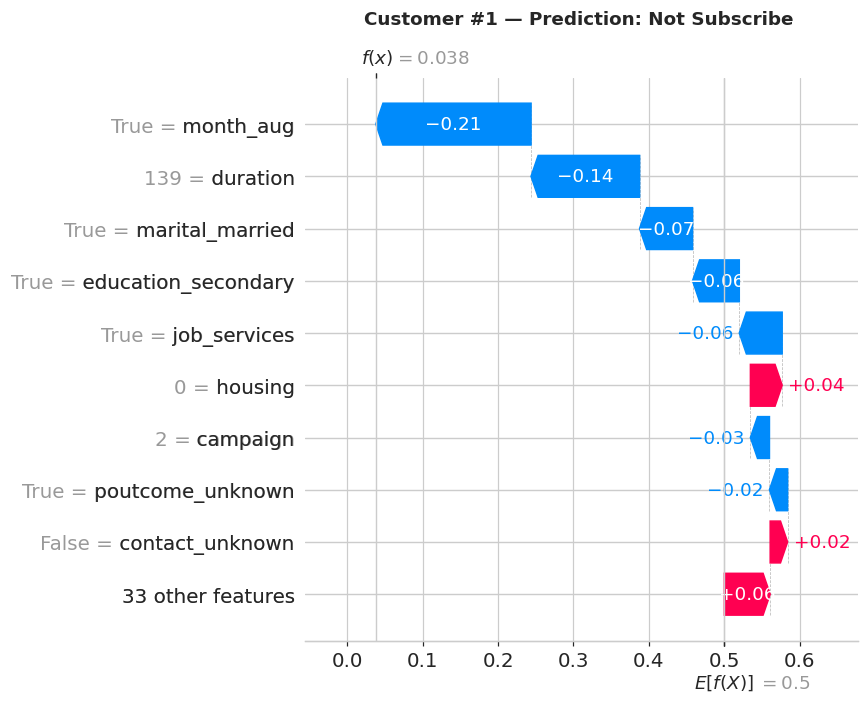

In [32]:
# ── SHAP Waterfall Charts for 5 Individual Customers (One per Figure) ───────

for plot_i, cust_idx in enumerate(chosen):
    fig, ax = plt.subplots(figsize=(12, 5))  #  separate figure per customer

    plt.sca(ax)
    shap.waterfall_plot(
        exp_yes[cust_idx],
        max_display=10,
        show=False
    )

    pred_lbl = 'Subscribe ' if rf.predict(X_test_sample.iloc[[cust_idx]])[0] == 1 else 'Not Subscribe '

    plt.title(
        f'Customer #{cust_idx} — Prediction: {pred_lbl}',
        fontsize=12, fontweight='bold', pad=15
    )

    plt.tight_layout()
    plt.show()        #  show & close each figure before drawing next one
    print()           # spacing between charts

In [33]:
# ── SHAP Force Plot for Customer #0 (interactive HTML) ─────────────────────
shap.initjs()
shap.force_plot(
    base_value    = explainer.expected_value[1],
    shap_values   = sv_yes[chosen[0]],
    features      = X_test_sample.iloc[chosen[0]],
    feature_names = X_test_sample.columns.tolist()
)

##  Step 9: Final Model Comparison Summary


           FINAL MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8848     0.5084  0.4556    0.4806   0.8723
Random Forest          0.8986     0.5610  0.6125    0.5856   0.9194

 Best Model by F1-Score : Random Forest
   Recommendation         : Use Random Forest for production deployment.

 Key Insights:
   - "duration" (call duration) is the strongest predictive feature
   - Longer calls → higher probability of subscription
   - Previous campaign outcome (poutcome) is also highly influential
   - SMOTE helped balance classes — improving recall for minority (YES) class


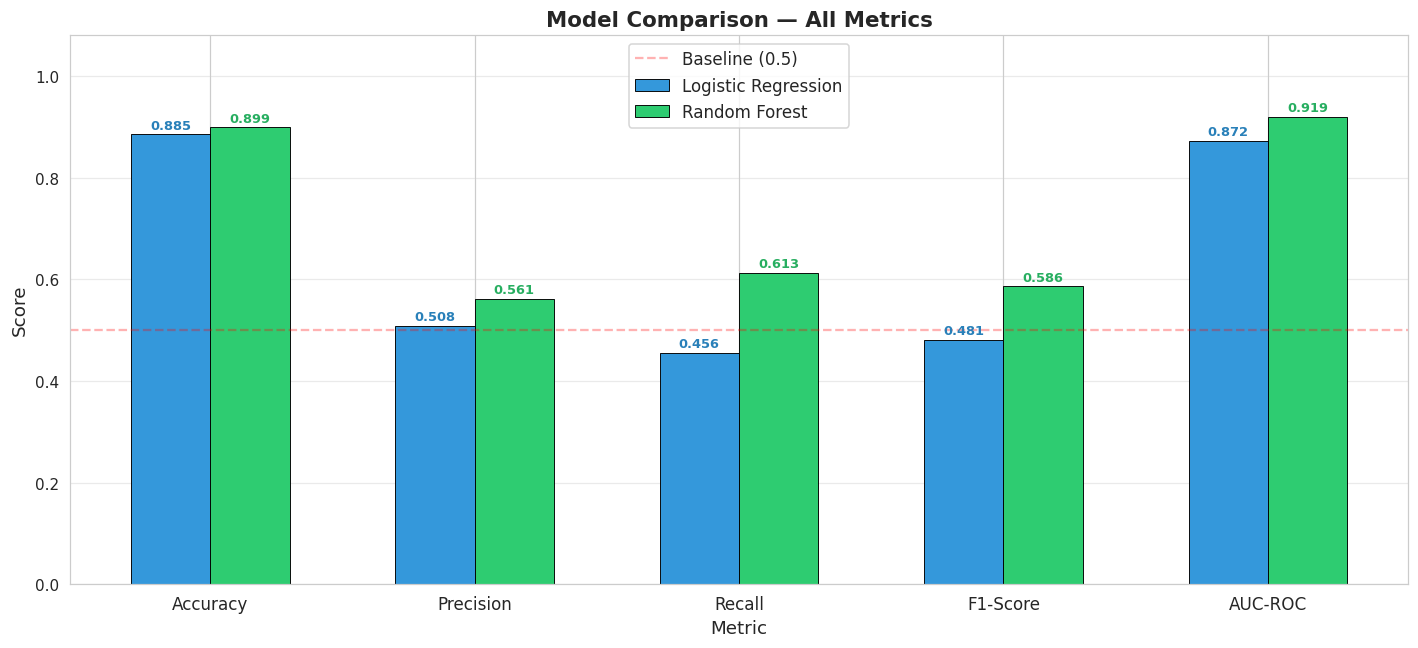


  METRIC-BY-METRIC WINNER
  Accuracy     →  LR: 0.8848  |  RF: 0.8986  |  Winner: Random Forest       
  Precision    →  LR: 0.5084  |  RF: 0.5610  |  Winner: Random Forest       
  Recall       →  LR: 0.4556  |  RF: 0.6125  |  Winner: Random Forest       
  F1-Score     →  LR: 0.4806  |  RF: 0.5856  |  Winner: Random Forest       
  AUC-ROC      →  LR: 0.8723  |  RF: 0.9194  |  Winner: Random Forest       


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ── Build Summary Table ──────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'AUC-ROC': [auc_lr, auc_rf]
})

summary = summary.set_index('Model').round(4)

# ── Print Text Table ─────────────────────────────────────────────────────────
print('\n' + '='*65)
print('           FINAL MODEL COMPARISON SUMMARY')
print('='*65)
print(summary.to_string())
print('='*65)

best = summary['F1-Score'].idxmax()
print(f'\n Best Model by F1-Score : {best}')
print(f'   Recommendation         : Use {best} for production deployment.')
print('\n Key Insights:')
print('   - "duration" (call duration) is the strongest predictive feature')
print('   - Longer calls → higher probability of subscription')
print('   - Previous campaign outcome (poutcome) is also highly influential')
print('   - SMOTE helped balance classes — improving recall for minority (YES) class')

# ── Visual Bar Chart Comparison ──────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x       = np.arange(len(metrics))
width   = 0.30

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, summary.loc['Logistic Regression', metrics],
               width, label='Logistic Regression', color='#3498db',
               edgecolor='black', linewidth=0.6)

bars2 = ax.bar(x + width/2, summary.loc['Random Forest', metrics],
               width, label='Random Forest', color='#2ecc71',
               edgecolor='black', linewidth=0.6)

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#2980b9')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#27ae60')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.08)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='Baseline (0.5)')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

# ── Winner Highlight ─────────────────────────────────────────────────────────
print('\n' + '='*65)
print('  METRIC-BY-METRIC WINNER')
print('='*65)
for metric in metrics:
    lr_val = summary.loc['Logistic Regression', metric]
    rf_val = summary.loc['Random Forest', metric]
    winner = 'Random Forest       ' if rf_val >= lr_val else 'Logistic Regression '
    print(f'  {metric:<12} →  LR: {lr_val:.4f}  |  RF: {rf_val:.4f}  |  Winner: {winner}')
print('='*65)